LOADING Data

1. Cell 1: Setup & Dependencies (Ensure Drive Mount)

In [ ]:
# Cell 1: Setup & Dependencies & Global Constants

from google.colab import drive
import pandas as pd
from datetime import datetime, timedelta, time
import numpy as np
import joblib # For saving/loading ML model

# Scikit-learn imports (keep them here as they are used in Cell 4)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- Mount Google Drive (if your dataset is there, or upload directly) ---
drive.mount('/content/drive', force_remount=True) # force_remount=True can help prevent 'already mounted' issues

# --- Install necessary libraries ---
# Only install if not already satisfied. Colab often has these pre-installed.
!pip install pandas flask pyngrok python-dotenv scikit-learn joblib matplotlib

# --- Global Constants for the entire project ---
# 1. Path to your dataset
DATA_FILE_PATH = '/content/drive/MyDrive/household_power_consumption.txt'

# 2. ML Model Path
MODEL_PATH = '/content/trained_appliance_classifier.joblib'

# 3. Features used for ML training and prediction
ML_FEATURES = ['Global_active_power', 'hour', 'day_of_week', 'day_of_year', 'month', 'power_diff_1']

# 4. Appliance Category Mapping (from category ID to descriptions)
appliance_category_map = {
    0: {"name": "Baseload/Other", "appliances": "Router, Standby Devices, Unmetered Loads", "impact": "Constant"},
    1: {"name": "Kitchen/Dishwashing", "appliances": "Dishwasher, Oven, Microwave, other kitchen appliances", "impact": "Intermittent High"},
    2: {"name": "Laundry/Water Heating", "appliances": "Washing Machine, Electric Dryer, Electric Water Heater", "impact": "Medium-Duration High"},
    3: {"name": "Cooling/Cooking", "appliances": "Air Conditioner, Electric Cooker", "impact": "Significant Continuous/Peak"},
}

# 5. Daily Budgets for each category (in kWh) - used for daily and monthly reports
DAILY_BUDGETS = {
    "Baseload/Other": 10.0,
    "Kitchen/Dishwashing": 5.0,
    "Laundry/Water Heating": 8.0,
    "Cooling/Cooking": 12.0,
}

# 6. Pie Chart Colors for consistent visualization
PIE_CHART_COLORS = {
    "Baseload/Other": '#a2d2ff',
    "Kitchen/Dishwashing": '#ffafcc',
    "Laundry/Water Heating": '#cdb4db',
    "Cooling/Cooking": '#bde0fe',
    # Add more if you expect other categories, or a default will be used
}

# 7. Carbon Emission Factor (average kg CO2 per kWh)
CARBON_FACTOR_KG_PER_KWH = 0.5 # Example: 0.5 kg CO2 per kWh (This varies by region)

print("Setup complete and global constants defined.")

Mounted at /content/drive
Setup complete and global constants defined.


Cell 2: Data Ingestion & Initial Cleaning

In [ ]:
# Path to your dataset (adjust if you uploaded directly to Colab or elsewhere)
# DATA_FILE_PATH = '/content/drive/MyDrive/household_power_consumption.txt'
DATA_FILE_PATH = '/content/drive/MyDrive/household_power_consumption.txt' # Assuming direct upload

print("Starting data parsing and loading...")

df = pd.read_csv(
    DATA_FILE_PATH,
    sep=';',
    parse_dates={'timestamp': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values=['?'],
    low_memory=False,
    dtype={
        'Global_active_power': float,
        'Global_reactive_power': float,
        'Voltage': float,
        'Global_intensity': float,
        'Sub_metering_1': float,
        'Sub_metering_2': float,
        'Sub_metering_3': float,
    }
)

original_rows = len(df)
df.dropna(subset=['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'], inplace=True) # Drop NaNs also in sub_metering for ML
print(f"Removed {original_rows - len(df)} rows due to missing critical power data (Global or Sub-metering).")

df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

print(f"Data loaded and cleaned. Total rows: {len(df)}")
print(df.head())
print(df.info())

# Ensure Global_active_power is numeric after cleaning
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

Starting data parsing and loading...


/tmp/ipykernel_288/3590346398.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_288/3590346398.py:7: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipykernel_288/3590346398.py:7: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


Removed 25979 rows due to missing critical power data (Global or Sub-metering).
Data loaded and cleaned. Total rows: 2049280
                     Global_active_power  Global_reactive_power  Voltage  \
timestamp                                                                  
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
timestamp                                                               
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             

Cell 3: Feature Engineering for ML: Look at Category

In [ ]:
print("Starting Feature Engineering for ML...")

# Create time-based features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek # Monday=0, Sunday=6
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month

# Create power-change features (lagged features)
df['power_lag_1'] = df['Global_active_power'].shift(1)
df['power_diff_1'] = df['Global_active_power'] - df['power_lag_1']

# Create interaction features (e.g., global power * sub-metering)
# For this simplified model, let's keep it to global_active_power, time, and power_diff.
# The actual sub-metering values will be used to create labels.

# Define Categories for Sub-metering:
# 0: Baseload/Low activity (all sub-meters low)
# 1: Sub_metering_1 dominant (Kitchen: Dishwasher, Oven, Microwave)
# 2: Sub_metering_2 dominant (Laundry: Washing Machine, Dryer; Electric Water Heater)
# 3: Sub_metering_3 dominant (Cooking: Electric Cooker; Cooling: Air Conditioner)

# Create the target variable: dominant_submeter_category
def get_dominant_submeter(row):
    # If Global_active_power is very low, consider it baseload/other
    if row['Global_active_power'] < 0.1: # Threshold for very low power in kW
        return 0

    sub_meters = {
        1: row['Sub_metering_1'],
        2: row['Sub_metering_2'],
        3: row['Sub_metering_3']
    }

    # Exclude 0 values if comparing dominant
    active_sub_meters = {k: v for k, v in sub_meters.items() if v > 0.05} # Threshold for activity in sub-meter

    if not active_sub_meters: # No significant sub-meter activity, but Global_active_power > 0.1, means unmetered
        return 0 # Or a separate 'Unmetered' category

    # Find the sub-meter with the maximum value among active ones
    dominant_meter_id = max(active_sub_meters, key=active_sub_meters.get)
    return dominant_meter_id

# Apply this function to create the target column
df['dominant_submeter_category'] = df.apply(get_dominant_submeter, axis=1)

# Drop rows with NaN values created by .shift()
df_ml = df.dropna(subset=['power_lag_1', 'power_diff_1']).copy()

print(f"ML-ready data shape: {df_ml.shape}")
print(df_ml[['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'power_diff_1', 'dominant_submeter_category']].head())
print(df_ml['dominant_submeter_category'].value_counts())

Starting Feature Engineering for ML...
ML-ready data shape: (2049279, 14)
                     Global_active_power  Sub_metering_1  Sub_metering_2  \
timestamp                                                                  
2006-12-16 17:25:00                5.360             0.0             1.0   
2006-12-16 17:26:00                5.374             0.0             2.0   
2006-12-16 17:27:00                5.388             0.0             1.0   
2006-12-16 17:28:00                3.666             0.0             1.0   
2006-12-16 17:29:00                3.520             0.0             2.0   

                     Sub_metering_3  hour  power_diff_1  \
timestamp                                                 
2006-12-16 17:25:00            16.0    17         1.144   
2006-12-16 17:26:00            17.0    17         0.014   
2006-12-16 17:27:00            17.0    17         0.014   
2006-12-16 17:28:00            17.0    17        -1.722   
2006-12-16 17:29:00            17.0    

Cell 4: Random Forest Classifier, Accuracy & Classification Report on Category

In [ ]:
print("Starting ML Model Training...")

# Features (X) and Target (y)
features = ['Global_active_power', 'hour', 'day_of_week', 'day_of_year', 'month', 'power_diff_1']
X = df_ml[features]
y = df_ml['dominant_submeter_category']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")

# Initialize and train the RandomForestClassifier
# n_estimators, max_depth, etc., can be tuned for better performance
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
model.fit(X_train, y_train)

print("Model training complete.")

# Evaluate the model
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Save the trained model to a file
MODEL_PATH = '/content/trained_appliance_classifier.joblib'
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")



Starting ML Model Training...
Training data shape: (1639423, 6), Test data shape: (409856, 6)
Model training complete.
Accuracy: 0.6571
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.64    120513
           1       0.63      0.39      0.48     17857
           2       0.47      0.38      0.42     79397
           3       0.74      0.79      0.76    192089

    accuracy                           0.66    409856
   macro avg       0.61      0.56      0.58    409856
weighted avg       0.65      0.66      0.65    409856

Model saved to /content/trained_appliance_classifier.joblib


Cell 5: Insight Generation Functions (Hybrid ML + Heuristics): Give humans advice

In [ ]:
print("Loading ML model and defining insight functions...")

# --- 1. Load the pre-trained ML model ---

loaded_model = joblib.load(MODEL_PATH)
print(f"ML model loaded from {MODEL_PATH}")

# --- 2. Define ML Features (MUST match features used during training in Cell 4) ---


# --- 3. Define Appliance Category Mapping (MUST match categories used during training in Cell 3) ---


# --- 4. Helper Functions for Data Retrieval ---
def get_data_for_day(dataframe: pd.DataFrame, target_date: datetime.date) -> pd.DataFrame:
    """Returns all half-hourly readings for a specific date."""
    start_of_day = datetime.combine(target_date, time.min)
    end_of_day = datetime.combine(target_date, time.max)
    return dataframe.loc[start_of_day:end_of_day].copy()

def get_data_for_period(dataframe: pd.DataFrame, start_date: datetime.date, end_date: datetime.date) -> pd.DataFrame:
    """Returns all half-hourly readings for a date range."""
    start_dt = datetime.combine(start_date, time.min)
    end_dt = datetime.combine(end_date, time.max)
    return dataframe.loc[start_dt:end_dt].copy()

# --- 5. Heuristic Insight Functions ---

def calculate_baseload(data_series: pd.Series, night_start_hour: int = 0, night_end_hour: int = 6) -> float:
    """Calculates the average lowest usage during predefined night hours."""
    if data_series.empty: return 0.0
    hourly_data = data_series.index.to_series().apply(lambda dt: dt.hour)
    night_data = data_series[(hourly_data >= night_start_hour) | (hourly_data < night_end_hour)]
    if night_data.empty: return 0.0
    return night_data.quantile(0.1)

def get_peak_hours(region: str = 'default') -> list[tuple[int, int]]:
    """Returns a list of peak hour ranges."""
    return [(17, 20)] # Example: 5 PM to 8 PM

def identify_night_owl_drain(day_data_df: pd.DataFrame, baseload: float, baseload_tolerance: float = 1.3) -> dict:
    """Checks for unusually high consumption during deep night hours compared to baseload."""
    night_start_hour = 0; night_end_hour = 6 # 12 AM to 6 AM
    night_period_data = day_data_df[(day_data_df.index.hour >= night_start_hour) | (day_data_df.index.hour < night_end_hour)]
    if night_period_data.empty: return {"detected": False, "message": "No data for night hours."}
    avg_night_power = night_period_data['Global_active_power'].mean()
    if avg_night_power > baseload * baseload_tolerance:
        return {"detected": True, "message": f"Nighttime usage ({avg_night_power:.2f} kW) is significantly higher than your typical baseload ({baseload:.2f} kW)! Check for devices left on overnight.", "value": avg_night_power}
    return {"detected": False, "message": "Nighttime usage is normal."}

def calculate_shift_and_save(day_data_df: pd.DataFrame, peak_hours: list[tuple[int, int]], peak_rate: float, offpeak_rate: float) -> dict:
    """Calculates potential savings if high usage during peak hours were shifted to off-peak."""
    peak_usage_kwh = 0.0
    for start_hour, end_hour in peak_hours:
        peak_period_data = day_data_df[(day_data_df.index.hour >= start_hour) & (day_data_df.index.hour < end_hour)]
        peak_usage_kwh += peak_period_data['Global_active_power'].sum() * 0.5 # 0.5 hours per reading
    if peak_usage_kwh <= 0: return {"detected": False, "message": "No significant usage during peak hours detected."}
    cost_at_peak = peak_usage_kwh * peak_rate; cost_at_offpeak = peak_usage_kwh * offpeak_rate
    potential_savings = cost_at_peak - cost_at_offpeak
    if potential_savings > 0.1: # Only report if meaningful savings
        # FIX FOR SYNTAXWARNING: Removed backslash before $
        return {"detected": True, "message": f"You used {peak_usage_kwh:.1f} kWh during peak hours. Shifting this could save you ${potential_savings:.2f}!", "peak_usage_kwh": peak_usage_kwh, "potential_savings": potential_savings}
    return {"detected": False, "message": "Minimal potential savings from shifting peak usage."}

def detect_anomaly(current_day_data_df: pd.DataFrame, comparison_data_df: pd.DataFrame, threshold_percent: float = 0.2) -> dict:
    """Compares current day's total usage to the average of a comparison period."""
    if comparison_data_df.empty: return {"detected": False, "message": "Not enough historical data for anomaly detection."}
    current_day_total_kwh = current_day_data_df['Global_active_power'].sum() * 0.5
    daily_totals_kwh = comparison_data_df.groupby(comparison_data_df.index.date)['Global_active_power'].sum() * 0.5
    avg_comparison_total_kwh = daily_totals_kwh.mean()
    if avg_comparison_total_kwh == 0: return {"detected": False, "message": "Average historical usage is zero, cannot detect anomaly."}
    percentage_change = (current_day_total_kwh - avg_comparison_total_kwh) / avg_comparison_total_kwh
    if percentage_change > threshold_percent:
        return {"detected": True, "message": f"Your energy usage today ({current_day_total_kwh:.1f} kWh) is {percentage_change*100:.0f}% higher than your average last week! Any new habits?", "current_usage": current_day_total_kwh, "average_usage": avg_comparison_total_kwh}
    elif percentage_change < -threshold_percent:
         return {"detected": True, "message": f"Great job! Your energy usage today ({current_day_total_kwh:.1f} kWh) is {abs(percentage_change*100):.0f}% lower than your average last week. Keep it up!", "current_usage": current_day_total_kwh, "average_usage": avg_comparison_total_kwh}
    return {"detected": False, "message": "Usage within normal limits."}

# --- 6. ML-driven Appliance Inference Function ---
def infer_appliance_type_ml(day_data_df: pd.DataFrame, baseload: float, model, ml_features: list[str]) -> list[dict]:
    """
    Uses the trained ML model to predict appliance categories for a given day's data,
    and summarizes them into user-friendly inferences.
    """
    inferences = []

    if day_data_df.empty:
        inferences.append({"type": "General", "message": "No energy data available for this day.",
                           "ml_category_name": "N/A", "likely_appliances": "N/A", "impact": "None"})
        return inferences

    day_data_for_ml = day_data_df.copy()
    day_data_for_ml['hour'] = day_data_for_ml.index.hour
    day_data_for_ml['day_of_week'] = day_data_for_ml.index.dayofweek
    day_data_for_ml['day_of_year'] = day_data_for_ml.index.dayofyear
    day_data_for_ml['month'] = day_data_for_ml.index.month
    day_data_for_ml['power_lag_1'] = day_data_for_ml['Global_active_power'].shift(1)
    day_data_for_ml['power_diff_1'] = day_data_for_ml['Global_active_power'] - day_data_for_ml['power_lag_1']

    day_data_for_ml.dropna(subset=['power_lag_1', 'power_diff_1'], inplace=True)

    if day_data_for_ml.empty or not all(f in day_data_for_ml.columns for f in ml_features):
        inferences.append({"type": "ML Inference", "message": "Not enough data or features to run ML appliance inference for this day.",
                           "ml_category_name": "N/A", "likely_appliances": "N/A", "impact": "N/A"})
        return inferences

    predictions = model.predict(day_data_for_ml[ml_features])
    day_data_for_ml['predicted_category'] = predictions

    current_category = -1
    start_time_of_event = None
    event_readings_count = 0 # Count number of 30-min readings in an event

    for i in range(len(day_data_for_ml)):
        time_index = day_data_for_ml.index[i]
        predicted_cat = day_data_for_ml['predicted_category'].iloc[i]
        power_level = day_data_for_ml['Global_active_power'].iloc[i]

        # Filter out very low power events as non-significant (mostly baseload or noise)
        if power_level < baseload * 1.2: # If power is not significantly above baseload, categorize as baseload
            predicted_cat = 0 # Force to baseload category for filtering

        if predicted_cat != current_category:
            if current_category != -1 and event_readings_count > 0:
                # End of previous event, summarize it
                if current_category != 0: # Don't summarize baseload as a distinct "event"
                    category_info = appliance_category_map.get(current_category, {"name": "Unknown", "appliances": "Unknown", "impact": "N/A"})
                    duration_hours = event_readings_count * 0.5

                    if duration_hours >= 0.5: # Only report if sustained for at least 30 mins
                        event_slice = day_data_for_ml.loc[start_time_of_event : day_data_for_ml.index[i-1]]
                        if not event_slice.empty: # Ensure slice is not empty
                            inferences.append({
                                "type": "ML Appliance Prediction",
                                "message": f"From {start_time_of_event.strftime('%H:%M')} for ~{duration_hours:.1f} hours, the pattern suggests activity related to '{category_info['name']}'.",
                                "ml_category_name": category_info['name'],
                                "likely_appliances": category_info['appliances'],
                                "impact": category_info['impact'],
                                "time_of_event": start_time_of_event.isoformat(),
                                "duration_hours": duration_hours,
                                "avg_power_in_event": event_slice['Global_active_power'].mean()
                            })
            # Start new event
            current_category = predicted_cat
            start_time_of_event = time_index
            event_readings_count = 1
        else:
            event_readings_count += 1

    # Add the last event if it extends to the end of the day
    if current_category != -1 and event_readings_count > 0 and current_category != 0:
        category_info = appliance_category_map.get(current_category, {"name": "Unknown", "appliances": "Unknown", "impact": "N/A"})
        duration_hours = event_readings_count * 0.5
        if duration_hours >= 0.5:
             event_slice = day_data_for_ml.loc[start_time_of_event : day_data_for_ml.index[-1]]
             if not event_slice.empty:
                inferences.append({
                    "type": "ML Appliance Prediction",
                    "message": f"From {start_time_of_event.strftime('%H:%M')} for ~{duration_hours:.1f} hours, the pattern suggests activity related to '{category_info['name']}'.",
                    "ml_category_name": category_info['name'],
                    "likely_appliances": category_info['appliances'],
                    "impact": category_info['impact'],
                    "time_of_event": start_time_of_event.isoformat(),
                    "duration_hours": duration_hours,
                    "avg_power_in_event": event_slice['Global_active_power'].mean()
                })

    # Add general baseload info explicitly at the beginning
    if baseload > 0.05:
        inferences.insert(0, { # Insert at the beginning
            "type": "Baseload",
            "message": f"Your baseline energy usage (around {baseload:.2f} kW) covers essential devices like your fridge and router. Optimizing these can offer small but continuous savings.",
            "ml_category_name": appliance_category_map[0]['name'],
            "likely_appliances": appliance_category_map[0]['appliances'],
            "impact": appliance_category_map[0]['impact']
        })

    # Sort inferences by time of event if present
    inferences.sort(key=lambda x: x.get("time_of_event", "ZZZ"))

    return inferences

print("All insight functions (ML-driven and heuristic) defined.")

Loading ML model and defining insight functions...
ML model loaded from /content/trained_appliance_classifier.joblib
All insight functions (ML-driven and heuristic) defined.


Cell 6: Sample Report

---



In [ ]:
import pandas as pd
import joblib

# 1. LOAD the CSV file
file_path = 'new_household_data_test.csv'
new_data = pd.read_csv(file_path)

# 2. PREPARE the data for the AI
new_data['Timestamp'] = pd.to_datetime(new_data['Timestamp'])
new_data.set_index('Timestamp', inplace=True)

# Add the 'clues' the AI needs
new_data['hour'] = new_data.index.hour
new_data['day_of_week'] = new_data.index.dayofweek
new_data['day_of_year'] = new_data.index.dayofyear
new_data['month'] = new_data.index.month
new_data['Global_active_power'] = new_data['Usage_kW']
new_data['power_diff_1'] = new_data['Global_active_power'].diff().fillna(0)

# 3. AI PREDICTION (Guess the appliances)
ML_FEATURES = ['Global_active_power', 'hour', 'day_of_week', 'day_of_year', 'month', 'power_diff_1']
predictions = loaded_model.predict(new_data[ML_FEATURES])
new_data['Category_ID'] = predictions
new_data['Appliance_Guess'] = new_data['Category_ID'].map(lambda x: appliance_category_map[x]['name'])

# 4. NOW RUN YOUR AUDIT REPORT
daily_usage = new_data.groupby(new_data.index.date).agg({
    'Usage_kW': ['sum', 'max'],
    'Appliance_Guess': lambda x: x.mode()[0]
})

daily_usage.columns = ['Total_Daily_Score', 'Peak_Power', 'Main_Appliance']

print("--- 📊 DAILY ENERGY AUDIT REPORT ---")
for date, row in daily_usage.iterrows():
    kwh = round(row['Total_Daily_Score'] / 2, 2)
    peak = round(row['Peak_Power'], 2)
    main_culprit = row['Main_Appliance']

    print(f"\n📅 DATE: {date}")
    print(f"Summary: You consumed {kwh} kWh today.")

    if kwh > 40:
        print(f"❗ ALERT: Your total usage is VERY HIGH.")

    if main_culprit == "Cooling/Cooking":
        print(f"⚠️ FEEDBACK: You used your Air Conditioner/Electric Cooker too much today.")
    elif main_culprit == "Laundry/Water Heating":
        print(f"⚠️ FEEDBACK: Laundry and Water Heating dominated your bill today.")
    elif main_culprit == "Kitchen/Dishwashing":
        print(f"⚠️ FEEDBACK: Your kitchen appliances were unusually active today.")

    print("-" * 40)

--- 📊 DAILY ENERGY AUDIT REPORT ---

📅 DATE: 2024-01-01
Summary: You consumed 41.03 kWh today.
❗ ALERT: Your total usage is VERY HIGH.
----------------------------------------

📅 DATE: 2024-01-02
Summary: You consumed 39.18 kWh today.
----------------------------------------

📅 DATE: 2024-01-03
Summary: You consumed 37.7 kWh today.
----------------------------------------

📅 DATE: 2024-01-04
Summary: You consumed 39.24 kWh today.
----------------------------------------

📅 DATE: 2024-01-05
Summary: You consumed 40.18 kWh today.
❗ ALERT: Your total usage is VERY HIGH.
----------------------------------------

📅 DATE: 2024-01-06
Summary: You consumed 38.7 kWh today.
----------------------------------------

📅 DATE: 2024-01-07
Summary: You consumed 38.7 kWh today.
----------------------------------------

📅 DATE: 2024-01-08
Summary: You consumed 37.24 kWh today.
----------------------------------------

📅 DATE: 2024-01-09
Summary: You consumed 40.61 kWh today.
❗ ALERT: Your total usage is

In [ ]:
import pandas as pd
import joblib

# 1. LOAD the CSV file
file_path = 'new_household_data_test.csv'
new_data = pd.read_csv(file_path)

# 2. PREPARE the data for the AI
new_data['Timestamp'] = pd.to_datetime(new_data['Timestamp'])
new_data.set_index('Timestamp', inplace=True)

# Add the 'clues' the AI needs
new_data['hour'] = new_data.index.hour
new_data['day_of_week'] = new_data.index.dayofweek
new_data['day_of_year'] = new_data.index.dayofyear
new_data['month'] = new_data.index.month
new_data['Global_active_power'] = new_data['Usage_kW']
new_data['power_diff_1'] = new_data['Global_active_power'].diff().fillna(0)

# --- ADD THIS LINE HERE ---
new_data['Date'] = new_data.index.date # Explicitly create a 'Date' column from the index

# 3. AI PREDICTION (Guess the appliances)
predictions = loaded_model.predict(new_data[ML_FEATURES])
new_data['Category_ID'] = predictions
new_data['Appliance_Guess'] = new_data['Category_ID'].map(lambda x: appliance_category_map[x]['name'])

# From here, you can run your report cells.
# You can remove the old audit code from this cell if you prefer to run audits in separate cells.

Pie Charts

Phase 4: Feedback Loops & User Engagement

#BEFORE

In [ ]:
def show_savings_potential(current_data):
    # 1. Calculate current totals
    current_kwh = current_data['Usage_kW'].sum() * 0.5

    # 2. SIMULATE the Feedback Loop:
    # Let's assume the user followed our advice and cut "Cooling/Cooking" by 20%
    # and "Laundry" by 10%
    savings_data = current_data.copy()

    # Apply reductions to the simulated 'Future' data
    savings_data.loc[savings_data['Appliance_Guess'] == 'Cooling/Cooking', 'Usage_kW'] *= 0.8
    savings_data.loc[savings_data['Appliance_Guess'] == 'Laundry/Water Heating', 'Usage_kW'] *= 0.9

    new_kwh = savings_data['Usage_kW'].sum() * 0.5
    money_saved = (current_kwh - new_kwh) * 0.15 # Assuming $0.15 per kWh

    print("--- 🔄 FEEDBACK LOOP: SAVINGS POTENTIAL ---")
    print(f"Current Weekly Usage: {current_kwh:.2f} kWh")
    print(f"Projected Usage (if advice followed): {new_kwh:.2f} kWh")
    print(f"💰 Potential Savings: ${money_saved:.2f} per week")


# Run it
show_savings_potential(new_data)

--- 🔄 FEEDBACK LOOP: SAVINGS POTENTIAL ---
Current Weekly Usage: 1174.13 kWh
Projected Usage (if advice followed): 1050.09 kWh
💰 Potential Savings: $18.61 per week


AFTER

In [ ]:
def manual_validation_loop(data):
    # Pick a random high-usage point to show the user
    sample = data[data['Usage_kW'] > 3.0].sample(1)
    time = sample.index[0]
    guess = sample['Appliance_Guess'].values[0]
    usage = sample['Usage_kW'].values[0]

    print(f"--- 🧠 AI VALIDATION LOOP ---")
    print(f"On {time}, the AI detected {usage}kW and guessed: '{guess}'")

    # In a real app, the user would click a button. Here, we use an input box.
    feedback = input("Was this guess correct? (y/n): ")

    if feedback.lower() == 'y':
        print("✅ Feedback received! AI confidence increased for this pattern.")
    else:
        correct_label = input("What was actually running? ")
        print(f"📝 Feedback received! Pattern re-labeled as '{correct_label}' for future training.")

# Run it
manual_validation_loop(new_data)

--- 🧠 AI VALIDATION LOOP ---
On 2024-01-15 20:00:00, the AI detected 4.466kW and guessed: 'Kitchen/Dishwashing'
Was this guess correct? (y/n): y
✅ Feedback received! AI confidence increased for this pattern.


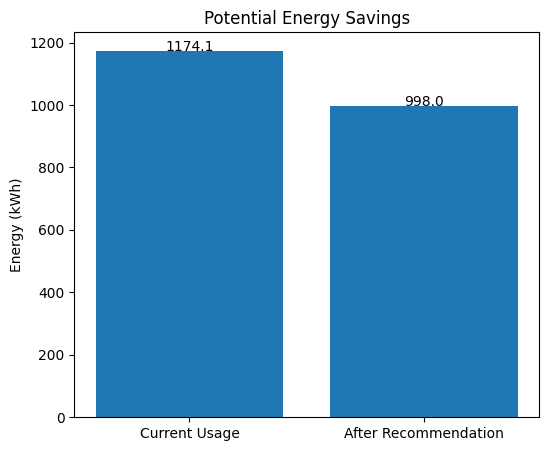

⚡ AI ENERGY COACH

Insight:
Following the recommended changes could reduce electricity consumption
by approximately 176.1 kWh per day.

Recommendation:
Reduce appliance usage during peak hours today.

GreenUp Task:
Set your AC to 25°C or delay laundry until off-peak hours.
Upload proof to earn GreenUp credits.



In [ ]:
import matplotlib.pyplot as plt

def plot_savings_impact_with_ai(data):

    data = data.copy()
    data['Energy_kWh'] = data['Usage_kW'] * 0.5

    current_usage = data['Energy_kWh'].sum()
    improved_usage = current_usage * 0.85
    savings = current_usage - improved_usage

    scenarios = ['Current Usage', 'After Recommendation']
    values = [current_usage, improved_usage]

    # ---------- CHART ----------
    plt.figure(figsize=(6,5))
    plt.bar(scenarios, values)

    plt.title("Potential Energy Savings")
    plt.ylabel("Energy (kWh)")

    for i,v in enumerate(values):
        plt.text(i, v + 0.2, f"{v:.1f}", ha='center')

    plt.show()

    # ---------- AI INSIGHT ----------
    print("⚡ AI ENERGY COACH")

    print(f"""
Insight:
Following the recommended changes could reduce electricity consumption
by approximately {savings:.1f} kWh per day.

Recommendation:
Reduce appliance usage during peak hours today.

GreenUp Task:
Set your AC to 25°C or delay laundry until off-peak hours.
Upload proof to earn GreenUp credits.
""")

plot_savings_impact_with_ai(new_data)

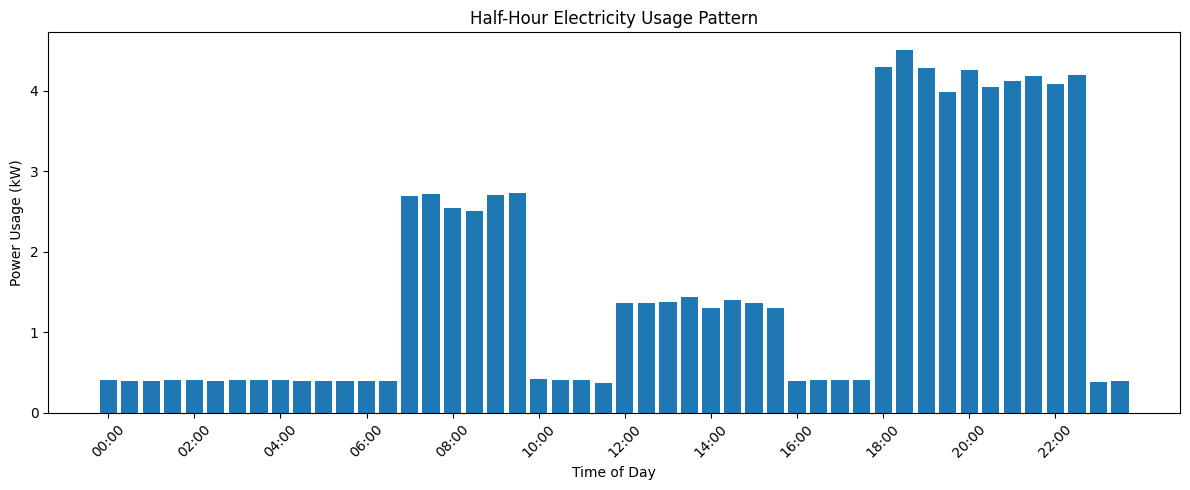

AI ENERGY COACH

Insight:
Electricity usage peaks around 18:00.

This suggests that multiple appliances are active during this period.

Recommendation:
Avoid running several high-power appliances simultaneously during this time.
Consider shifting activities like laundry or dishwashing to later hours.



In [ ]:
import matplotlib.pyplot as plt

def plot_half_hour_pattern_with_ai(data):

    data = data.copy()

    # ---------- CHART ----------
    data['time'] = data.index.time
    usage = data.groupby('time')['Usage_kW'].mean()

    plt.figure(figsize=(12,5))
    plt.bar(range(len(usage)), usage)

    plt.title("Half-Hour Electricity Usage Pattern")
    plt.xlabel("Time of Day")
    plt.ylabel("Power Usage (kW)")

    ticks = range(0, len(usage), 4)
    labels = [list(usage.index)[i].strftime("%H:%M") for i in ticks]

    plt.xticks(ticks, labels, rotation=45)

    plt.tight_layout()
    plt.show()

    # ---------- AI INSIGHT ----------
    data['hour'] = data.index.hour
    data['Energy_kWh'] = data['Usage_kW'] * 0.5

    hourly_usage = data.groupby('hour')['Energy_kWh'].sum()
    peak_hour = hourly_usage.idxmax()

    print("AI ENERGY COACH")

    print(f"""
Insight:
Electricity usage peaks around {peak_hour}:00.

This suggests that multiple appliances are active during this period.

Recommendation:
Avoid running several high-power appliances simultaneously during this time.
Consider shifting activities like laundry or dishwashing to later hours.
""")

# Run it
plot_half_hour_pattern_with_ai(new_data)

## Peak vs Non-peak

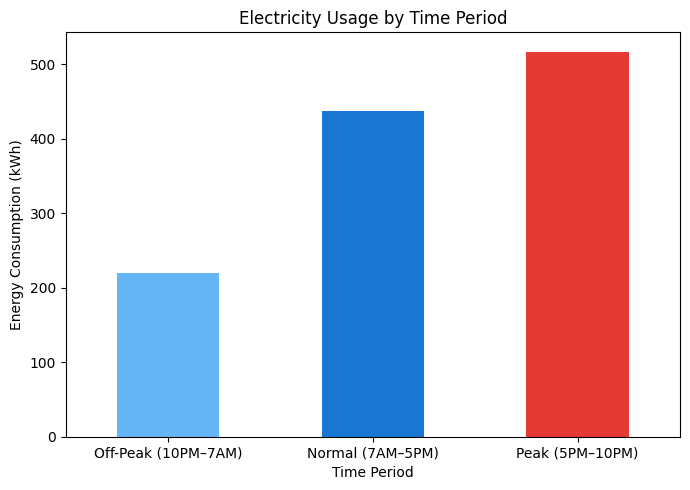

⚡ AI ENERGY COACH

Insight:
44.0% of electricity consumption occurs during peak demand hours (5 PM – 10 PM).

The highest electricity usage occurs around 18:00.

Recommendation:
Avoid running multiple high-power appliances between 5 PM and 10 PM.

Try shifting activities such as laundry, dishwashing or charging
devices to after 10 PM when electricity demand is lower.



In [ ]:
import matplotlib.pyplot as plt

def plot_peak_usage_with_ai(data):

    data = data.copy()
    data['hour'] = data.index.hour

    # ---------- CLASSIFY TIME ----------
    def classify_time(hour):
        if 17 <= hour < 22:
            return "Peak (5PM–10PM)"
        elif 22 <= hour or hour < 7:
            return "Off-Peak (10PM–7AM)"
        else:
            return "Normal (7AM–5PM)"

    data['Time_Category'] = data['hour'].apply(classify_time)

    # Convert to kWh (30 min interval)
    data['Energy_kWh'] = data['Usage_kW'] * 0.5

    usage = data.groupby('Time_Category')['Energy_kWh'].sum()

    usage = usage.reindex([
        "Off-Peak (10PM–7AM)",
        "Normal (7AM–5PM)",
        "Peak (5PM–10PM)"
    ])

    # ---------- CHART ----------
    plt.figure(figsize=(7,5))

    colors = [
        "#64B5F6",  # Off-peak
        "#1976D2",  # Normal
        "#E53935"   # Peak
    ]

    usage.plot(kind='bar', color=colors)

    plt.title("Electricity Usage by Time Period")
    plt.ylabel("Energy Consumption (kWh)")
    plt.xlabel("Time Period")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # ---------- AI INSIGHT ----------
    peak_energy = usage["Peak (5PM–10PM)"]
    total_energy = usage.sum()
    peak_pct = (peak_energy / total_energy) * 100

    hourly_usage = data.groupby('hour')['Energy_kWh'].sum()
    peak_hour = hourly_usage.idxmax()

    print("⚡ AI ENERGY COACH")

    print(f"""
Insight:
{peak_pct:.1f}% of electricity consumption occurs during peak demand hours (5 PM – 10 PM).

The highest electricity usage occurs around {peak_hour}:00.

Recommendation:
Avoid running multiple high-power appliances between 5 PM and 10 PM.

Try shifting activities such as laundry, dishwashing or charging
devices to after 10 PM when electricity demand is lower.
""")

plot_peak_usage_with_ai(new_data)

DAILY REPORT

--- 📱 App-Style Daily Energy Dashboard (Focused) ---

=============== 📅 Energy Breakdown - 30 Jan 2024 ===============



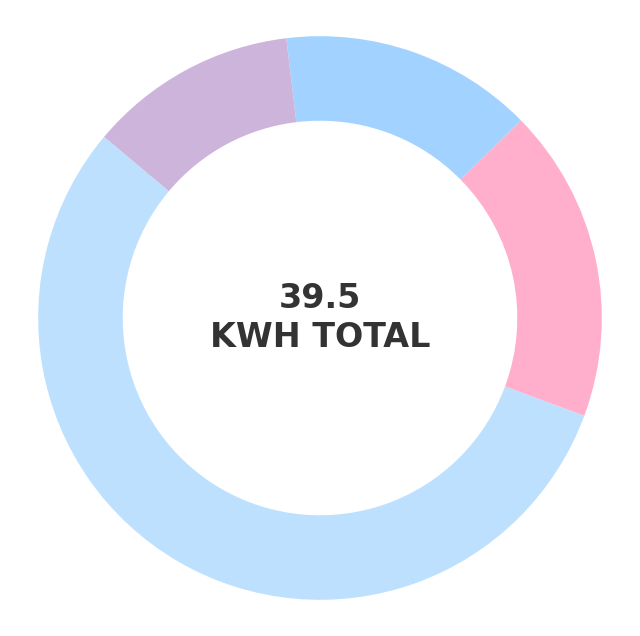

⚠️ Cooling/Cooking (55%) is your highest usage category

  ● Cooling/Cooking      21.9 kWh (55%)
  ● Kitchen/Dishwashing  7.1 kWh (18%)
  ● Baseload/Other       5.7 kWh (15%)
  ● Laundry/Water Heating 4.7 kWh (12%)


========== 🤖 JouleBuddy Personalised Insight ==========
💡 Cooling/Cooking accounted for 55% of your energy today. Look for savings from air conditioner.


=============== 📅 Energy Breakdown - 29 Jan 2024 ===============



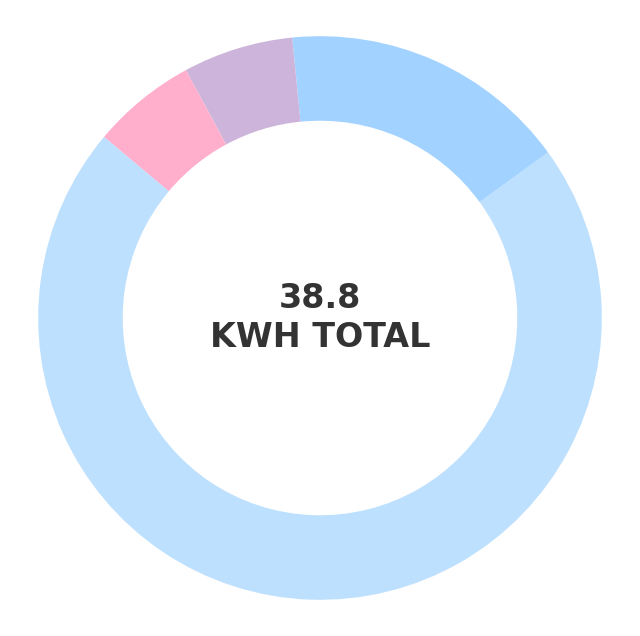

⚠️ Cooling/Cooking (71%) is your highest usage category

  ● Cooling/Cooking      27.6 kWh (71%)
  ● Baseload/Other       6.4 kWh (17%)
  ● Laundry/Water Heating 2.5 kWh (6%)
  ● Kitchen/Dishwashing  2.3 kWh (6%)


========== 🤖 JouleBuddy Personalised Insight ==========
💡 Cooling/Cooking accounted for 71% of your energy today. Look for savings from air conditioner.



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date, datetime

# --- Constants (These are now global from Cell 1, but listed here for clarity if copied elsewhere) ---
# PIE_CHART_COLORS
# DAILY_BUDGETS
# CARBON_FACTOR_KG_PER_KWH
# appliance_category_map


# --- Function to generate a single day's app-style pie chart and direct info ---
def generate_focused_daily_pie_dashboard(current_day_date, data_for_day):
    # Ensure 'Energy_kWh' is calculated for the chart
    if 'Energy_kWh' not in data_for_day.columns:
        data_for_day['Energy_kWh'] = data_for_day['Usage_kW'] * 0.5

    # Calculate daily kWh totals per category
    category_totals_for_day = data_for_day.groupby('Appliance_Guess')['Energy_kWh'].sum().sort_values(ascending=False)
    total_day_kwh = category_totals_for_day.sum()

    # Calculate percentages for display
    percentages = (category_totals_for_day / total_day_kwh) * 100 if total_day_kwh > 0 else (category_totals_for_day * 0)

    # Identify the highest usage category for the alert
    highest_category_name = ""
    highest_category_pct = 0
    highest_category_kwh = 0

    if not category_totals_for_day.empty and total_day_kwh > 0:
        highest_category_name = category_totals_for_day.index[0]
        highest_category_kwh = category_totals_for_day.iloc[0]
        highest_category_pct = percentages.iloc[0]

    # --- Print Header ---
    print(f"\n{'='*15} 📅 Energy Breakdown - {current_day_date.strftime('%d %b %Y')} {'='*15}\n")

    # --- 1. Donut Chart (with total in center) ---
    plt.figure(figsize=(8, 8))

    # Define colors for slices, using global PIE_CHART_COLORS
    pie_colors_for_day = [PIE_CHART_COLORS.get(cat, '#d9ed92') for cat in category_totals_for_day.index]

    if total_day_kwh > 0:
        plt.pie(category_totals_for_day,
                labels=[''] * len(category_totals_for_day), # No labels on slices for cleaner donut
                colors=pie_colors_for_day,
                wedgeprops={'width': 0.3}, # Create the donut hole
                startangle=140,
                pctdistance=0.85
               )

        # Add total KWH in the center
        plt.text(0, 0, f"{total_day_kwh:.1f}\nKWH TOTAL",
                 ha='center', va='center', fontsize=24, weight='bold', color='#333333')
        plt.axis('equal') # Ensures circular pie
        plt.show()
    else:
        print("No energy consumption data for this day to generate a chart.")
        print(f"Total: 0.0 KWH TOTAL")

    # --- 2. Highest Usage Category Alert (Mimicking the yellow box) ---
    if highest_category_pct > 0 and highest_category_pct > 20: # Only show if significant (e.g., >20%)
        print(f"⚠️ {highest_category_name} ({highest_category_pct:.0f}%) is your highest usage category\n")
    elif total_day_kwh > 0:
        print("💡 Your energy usage is well-distributed today, no single category dominates.\n")
    else:
        print("No significant usage recorded for categories.\n")


    # --- 3. Category Breakdown List (Mimicking the dots and KWh/percentage) ---
    for category, kwh_val in category_totals_for_day.items():
        pct_val = percentages.get(category, 0)
        # Use a small colored circle similar to the app UI
        color_dot = "●" # Placeholder, actual color can't be printed easily in text
        print(f"  {color_dot} {category.ljust(20)} {kwh_val:.1f} kWh ({pct_val:.0f}%)") # Using ljust for alignment
    print("\n")

    # --- 4. Simplified Personalized Insight (JouleBuddy style - without heavy text) ---
    print(f"{'='*10} 🤖 JouleBuddy Personalised Insight {'='*10}")
    if highest_category_pct > 0:
        # Get primary appliance for insight, e.g. "air conditioning" from "Cooling/Cooking"
        primary_appliance_for_insight = appliance_category_map[list(appliance_category_map.keys())[list(v['name'] for v in appliance_category_map.values()).index(highest_category_name)]]['appliances'].split(',')[0].strip().lower()

        print(f"💡 {highest_category_name} accounted for {highest_category_pct:.0f}% of your energy today. Look for savings from {primary_appliance_for_insight}.")
    else:
        print("💡 No major insights today; your usage is very low or well-balanced. Keep up the good work!")
    print(f"{'='*60}\n")


# --- Main function to generate Today and Yesterday's Simplified Dashboard ---
def generate_today_yesterday_pie_dashboard(full_data):
    print("--- 📱 App-Style Daily Energy Dashboard (Focused) ---")

    # Ensure 'Energy_kWh' and 'Date' columns are available
    if 'Energy_kWh' not in full_data.columns:
        full_data['Energy_kWh'] = full_data['Usage_kW'] * 0.5
    if 'Date' not in full_data.columns:
        full_data['Date'] = full_data.index.date

    # Get unique dates and sort them from most recent to oldest
    unique_dates = sorted(full_data['Date'].unique(), reverse=True)

    if not unique_dates:
        print("No data available to generate a report.")
        return

    today_date = unique_dates[0]
    yesterday_date = unique_dates[1] if len(unique_dates) > 1 else None

    # Report for Today
    today_data_filtered = full_data[full_data['Date'] == today_date]
    generate_focused_daily_pie_dashboard(today_date, today_data_filtered)

    # Report for Yesterday (if available)
    if yesterday_date:
        yesterday_data_filtered = full_data[full_data['Date'] == yesterday_date]
        generate_focused_daily_pie_dashboard(yesterday_date, yesterday_data_filtered)
    elif len(unique_dates) == 1:
        print("\nOnly one day of data available. Cannot provide a 'Yesterday' comparison in this format.")


# --- HOW TO RUN THIS FUNCTION ---
# Make sure you've run the cell that loads your data into 'new_data'
# and performs the AI predictions.
# Then, simply call the function:
generate_today_yesterday_pie_dashboard(new_data)

##MONTHLY REPORT

--- 📊 MONTHLY ENERGY AUDIT REPORT ---

==================== 📈 MONTH: 2024-01 ====================
Monthly Consumption: 1174.13 kWh (Equivalent to 587.06 kg CO2)
Peak Power Recorded: 5.39 kW


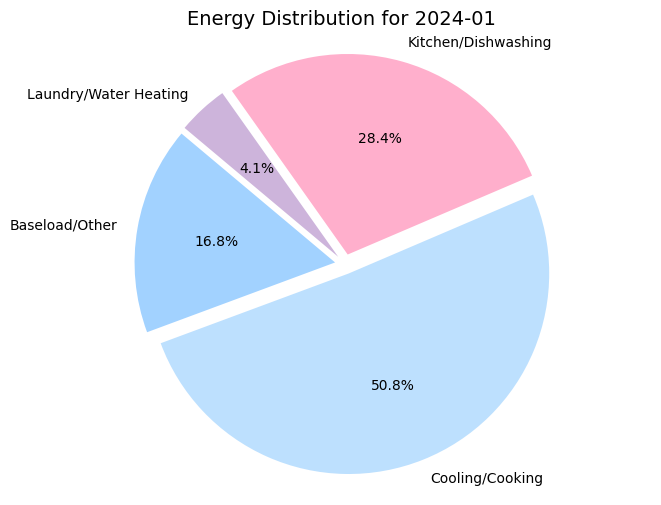


--- 🚨 MONTHLY ACTION REQUIRED ---
  • Your Cooling/Cooking was significantly over budget by 236.21 kWh this month. Consider proactive measures like smart thermostats and insulation to **manage seasonal demand on the grid.**
  • Your Kitchen/Dishwashing was over budget by 183.07 kWh this month. Optimize appliance usage and consider energy-efficient models to **align with broader energy consumption reduction goals.**

Monthly changes contribute significantly to your overall bill and environmental impact!



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date # For date comparisons if needed




# --- Main function to generate the Monthly Report ---
def generate_monthly_report(full_data):
    print("--- 📊 MONTHLY ENERGY AUDIT REPORT ---")

    # 1. Ensure 'Energy_kWh' and 'Date' columns are available
    if 'Energy_kWh' not in full_data.columns:
        full_data['Energy_kWh'] = full_data['Usage_kW'] * 0.5
    if 'Date' not in full_data.columns: # Re-add check for safety, though it should be there from loading
        full_data['Date'] = full_data.index.date

    # 2. Create a 'Month_Period' column for robust monthly grouping (e.g., '2024-01')
    full_data['Month_Period'] = full_data.index.to_period('M')

    # Get unique months and sort them chronologically
    unique_months = sorted(full_data['Month_Period'].unique())

    if not unique_months:
        print("No data available to generate a monthly report.")
        return

    # To track previous month's total for trend comparison
    previous_month_total_kwh = None

    for i, current_month_period in enumerate(unique_months):
        month_data = full_data[full_data['Month_Period'] == current_month_period]

        # Skip if no data for this month
        if month_data.empty:
            continue

        print(f"\n{'='*20} 📈 MONTH: {current_month_period} {'='*20}")

        # Calculate monthly totals
        total_monthly_kwh = month_data['Energy_kWh'].sum()
        total_monthly_co2 = total_monthly_kwh * CARBON_FACTOR_KG_PER_KWH
        peak_monthly_power = month_data['Usage_kW'].max()
        num_days_in_month_data = month_data['Date'].nunique() # Count actual days with data

        print(f"Monthly Consumption: {total_monthly_kwh:.2f} kWh (Equivalent to {total_monthly_co2:.2f} kg CO2)")
        print(f"Peak Power Recorded: {peak_monthly_power:.2f} kW")

        # --- Monthly Trend Comparison (if previous month data exists) ---
        if previous_month_total_kwh is not None:
            if previous_month_total_kwh > 0:
                kwh_change_pct = ((total_monthly_kwh - previous_month_total_kwh) / previous_month_total_kwh) * 100
                if kwh_change_pct > 15: # Over 15% increase
                    print(f"❗ TREND ALERT: Your total usage increased by {kwh_change_pct:.1f}% compared to last month! Review for potential savings.")
                elif kwh_change_pct < -10: # Over 10% decrease
                    print(f"✅ POSITIVE TREND: You reduced total usage by {abs(kwh_change_pct):.1f}% from last month! Keep up the great work!")
            else: # If previous month had 0 usage, and current month has usage
                print(f"❗ TREND ALERT: Significant increase in usage compared to last month (previous month had no recorded usage).")
        previous_month_total_kwh = total_monthly_kwh # Update for next iteration

        # --- Generate Pie Chart for THIS MONTH's breakdown ---
        category_totals_for_month = month_data.groupby('Appliance_Guess')['Energy_kWh'].sum()

        if not category_totals_for_month.empty:
            plt.figure(figsize=(8, 6))
            pie_colors_for_month = [PIE_CHART_COLORS.get(cat, '#d9ed92') for cat in category_totals_for_month.index]

            plt.pie(category_totals_for_month,
                    labels=category_totals_for_month.index,
                    autopct='%1.1f%%',
                    startangle=140,
                    colors=pie_colors_for_month,
                    explode=[0.05] * len(category_totals_for_month) if len(category_totals_for_month) > 1 else None
                   )
            plt.title(f'Energy Distribution for {current_month_period}', fontsize=14)
            plt.axis('equal')
            plt.show()
        else:
            print("No detailed category data for this month.")

        # --- Consolidated Monthly Alerts (based on dynamically calculated monthly budgets) ---
        monthly_issues = []

        for category, usage in category_totals_for_month.items():
            # Calculate monthly budget based on actual number of days with data in this month
            effective_monthly_budget = DAILY_BUDGETS.get(category, 10.0) * num_days_in_month_data

            if usage > effective_monthly_budget:
                diff = usage - effective_monthly_budget

                if "Cooling" in category:
                    advice = f"Your {category} was significantly over budget by {diff:.2f} kWh this month. Consider proactive measures like smart thermostats and insulation to **manage seasonal demand on the grid.**"
                elif "Laundry" in category:
                    advice = f"Your {category} was over budget by {diff:.2f} kWh this month. A high usage suggests opportunities for **long-term efficiency upgrades or habit changes.**"
                elif "Kitchen" in category:
                    advice = f"Your {category} was over budget by {diff:.2f} kWh this month. Optimize appliance usage and consider energy-efficient models to **align with broader energy consumption reduction goals.**"
                elif "Baseload" in category:
                     advice = f"Your {category} was over budget by {diff:.2f} kWh this month. Persistent high baseload impacts **overall grid efficiency; investigate 'always-on' devices.**"
                else:
                    advice = f"Your {category} was over budget by {diff:.2f} kWh this month. Review this category's persistent usage."

                monthly_issues.append(advice)

        if monthly_issues:
            print("\n--- 🚨 MONTHLY ACTION REQUIRED ---")
            for issue in monthly_issues:
                print(f"  • {issue}")
            print("\nMonthly changes contribute significantly to your overall bill and environmental impact!")
        else:
            print("\n✅ Great job this month! All appliance categories stayed within budget, supporting a stable grid and lower bills.")

        print(f"\n{'='*60}") # End of month separator


# --- HOW TO RUN THIS FUNCTION ---
# Make sure you've run the cell that loads your data into 'new_data'
# and performs the AI predictions.
# Then, simply call the function:
generate_monthly_report(new_data)

## Flask API Server Code (for react native)

In [ ]:
# Cell: Flask API Server for React Native App

from flask import Flask, request, jsonify
from pyngrok import ngrok # pyngrok needs to be imported here if running in Colab
import joblib
import pandas as pd
from datetime import datetime
import os # For environment variables, though not strictly needed if constants are global

# --- Flask App Initialization ---
app = Flask(__name__)

# --- Load the trained model (using the global MODEL_PATH) ---
# Ensure MODEL_PATH is defined in Cell 1 and the model file exists.
loaded_model = joblib.load(MODEL_PATH)

# --- API Endpoint for Prediction ---
@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 1. Get data from the React Native app
        data = request.get_json(force=True)

        # 2. Input Validation
        current_power_str = data.get('currentPower')
        timestamp_str = data.get('timestamp')
        power_diff_str = data.get('powerDiff') # Optional: app can send previous diff, default to 0.0

        if not isinstance(current_power_str, (int, float, str)) or not current_power_str:
            return jsonify({"status": "error", "message": "Invalid or missing 'currentPower'."}), 400
        if not isinstance(timestamp_str, str) or not timestamp_str:
            return jsonify({"status": "error", "message": "Invalid or missing 'timestamp'."}), 400

        try:
            current_power = float(current_power_str)
        except ValueError:
            return jsonify({"status": "error", "message": "'currentPower' must be a valid number."}), 400

        try:
            dt_object = datetime.fromisoformat(timestamp_str.replace('Z', '+00:00')) # Handle 'Z' for UTC
        except ValueError:
            return jsonify({"status": "error", "message": "'timestamp' must be a valid ISO 8601 string (e.g., '2024-01-01T15:30:00Z')."}), 400

        # Power_diff_1: If the app sends it, use it. Otherwise, assume 0 for a single point prediction.
        # This acknowledges the training vs. inference scale.
        power_diff_1 = 0.0
        if power_diff_str is not None:
            try:
                power_diff_1 = float(power_diff_str)
            except ValueError:
                # Log a warning, but proceed with default 0.0 if app sends invalid diff
                print(f"Warning: Invalid 'powerDiff' received: {power_diff_str}. Using default 0.0.")


        # 3. Prepare features for the ML model (using global ML_FEATURES)
        input_data = {
            'Global_active_power': current_power,
            'hour': dt_object.hour,
            'day_of_week': dt_object.weekday(), # Monday=0, Sunday=6
            'day_of_year': dt_object.timetuple().tm_yday,
            'month': dt_object.month,
            'power_diff_1': power_diff_1
        }

        # Create DataFrame ensuring column order matches ML_FEATURES
        features_df = pd.DataFrame([input_data])[ML_FEATURES]

        # 4. Make prediction
        prediction_id = loaded_model.predict(features_df)[0]
        prediction_info = appliance_category_map.get(prediction_id, {"name": "Unknown", "appliances": "N/A", "impact": "N/A"})

        # 5. Send answer back to the React Native app
        return jsonify({
            "status": "success",
            "prediction_id": int(prediction_id),
            "appliance_name": prediction_info["name"],
            "likely_appliances": prediction_info["appliances"],
            "impact": prediction_info["impact"]
        })

    except Exception as e:
        # Catch any unexpected server errors
        print(f"An unhandled error occurred: {e}")
        return jsonify({"status": "error", "message": "Internal server error. Please try again later."}), 500

# --- Running the Flask app ---
if __name__ == '__main__':
    # --- For Colab: Use pyngrok to expose the local Flask app to the internet ---
    # !pip install pyngrok (should be installed by Cell 1)
    # import os (if NGROK_AUTH_TOKEN is used)
    # os.environ["NGROK_AUTH_TOKEN"] = "YOUR_NGROK_AUTH_TOKEN" # Uncomment and add your token for stable tunnels
    public_url = ngrok.connect(5000)
    print(f" * Tunnel URL: {public_url}/predict")

    # --- Run Flask app ---
    # Use 0.0.0.0 for Colab/deployment to make it publicly accessible
    app.run(host='0.0.0.0', port=5000, use_reloader=False) # use_reloader=False for Colab stability